<a href="https://colab.research.google.com/github/rishanthvijay6-cmyk/PaperMind/blob/main/Banking_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Banking Marketing Campaign Analysis

## 🎯 Objective
The goal of this project is to analyze a marketing campaign dataset from a bank and build a predictive model to identify customers who are most likely to subscribe to a term deposit.

## 💼 Business Problem
Marketing campaigns are costly. The bank wants to:
- Improve conversion rates
- Reduce unnecessary customer contacts
- Target the right audience

## ✅ Solution Approach
- Perform data analysis to identify key patterns
- Build machine learning models to predict customer response
- Provide actionable business recommendations

In [11]:
# Basic libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

# Imbalance handling
from imblearn.over_sampling import SMOTE

In [12]:
df = pd.read_csv("banking_data.csv")  # change file name if needed

df.head()

,age,job,marital,marital_status,education,default,balance,housing,loan,contact,day,month,day_month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,married,tertiary,no,2143,yes,no,unknown,5,may,5-May,261,1,-1,0,unknown,no
1,44,technician,single,single,secondary,no,29,yes,no,unknown,5,may,5-May,151,1,-1,0,unknown,no
2,33,entrepreneur,married,married,secondary,no,2,yes,yes,unknown,5,may,5-May,76,1,-1,0,unknown,no
3,47,blue-collar,married,married,unknown,no,1506,yes,no,unknown,5,may,5-May,92,1,-1,0,unknown,no
4,33,unknown,single,single,unknown,no,1,no,no,unknown,5,may,5-May,198,1,-1,0,unknown,no


## 📌 Data Understanding
We explore dataset structure, types, and missing values.

In [13]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45216 entries, 0 to 45215
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             45216 non-null  int64 
 1   job             45216 non-null  object
 2   marital         45213 non-null  object
 3   marital_status  45213 non-null  object
 4   education       45213 non-null  object
 5   default         45216 non-null  object
 6   balance         45216 non-null  int64 
 7   housing         45216 non-null  object
 8   loan            45216 non-null  object
 9   contact         45216 non-null  object
 10  day             45216 non-null  int64 
 11  month           45216 non-null  object
 12  day_month       45216 non-null  object
 13  duration        45216 non-null  int64 
 14  campaign        45216 non-null  int64 
 15  pdays           45216 non-null  int64 
 16  previous        45216 non-null  int64 
 17  poutcome        45216 non-null  object
 18  y     

,0
age,0
job,0
marital,3
marital_status,3
education,3
default,0
balance,0
housing,0
loan,0
contact,0


Data Cleaning

In [14]:
# Check duplicates
df.drop_duplicates(inplace=True)

# Convert target variable to binary
df['y'] = df['y'].map({'yes':1, 'no':0})

In [15]:


print("\n" + "="*50)
print("OUTLIER HANDLING")
print("="*50)

# Store original shape
original_shape = df.shape

# Cap balance outliers at 99th percentile
balance_99 = df['balance'].quantile(0.99)
balance_outliers = (df['balance'] > balance_99).sum()
df['balance'] = df['balance'].clip(upper=balance_99)

# Cap duration outliers at 99th percentile
duration_99 = df['duration'].quantile(0.99)
duration_outliers = (df['duration'] > duration_99).sum()
df['duration'] = df['duration'].clip(upper=duration_99)

# Remove extreme age outliers
age_outliers = (df['age'] > 100).sum()
df = df[df['age'] <= 100]

print(f"✅ Capped {balance_outliers} balance outliers at {balance_99:.0f}")
print(f"✅ Capped {duration_outliers} duration outliers at {duration_99:.0f}")
print(f"✅ Removed {age_outliers} age outliers")
print(f"Shape: {original_shape} → {df.shape}")


OUTLIER HANDLING
✅ Capped 453 balance outliers at 13165
✅ Capped 452 duration outliers at 1269
✅ Removed 0 age outliers
Shape: (45211, 19) → (45211, 19)


Exploratory Data Analysis (EDA)
📊 Target Distribution

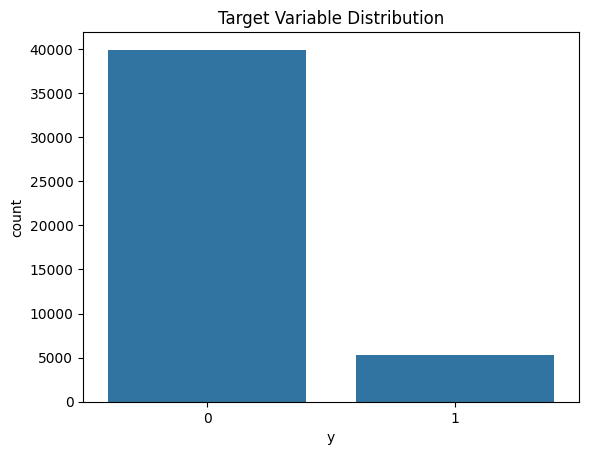

In [16]:
sns.countplot(x='y', data=df)
plt.title("Target Variable Distribution")
plt.show()

- The dataset is imbalanced (fewer 'yes' responses).
- This needs to be handled before modeling.

📊 Age Distribution

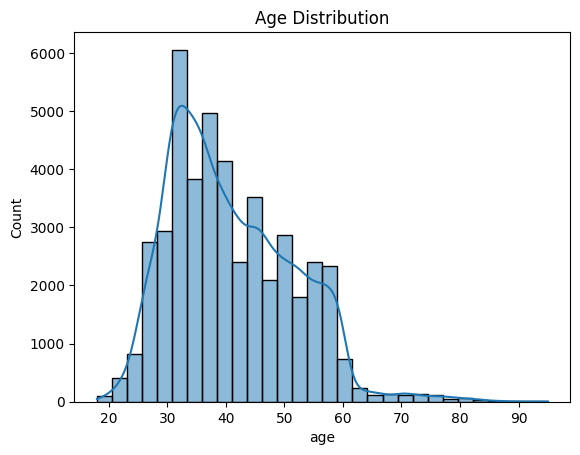

In [17]:
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

Job vs Subscription

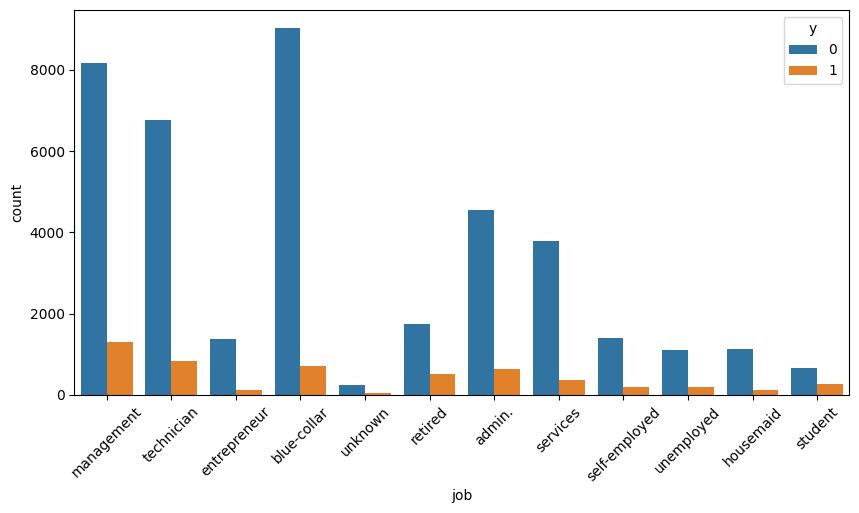

In [18]:
plt.figure(figsize=(10,5))
sns.countplot(x='job', hue='y', data=df)
plt.xticks(rotation=45)
plt.show()

- Certain job categories show higher conversion rates.

📊 Correlation Heatmap

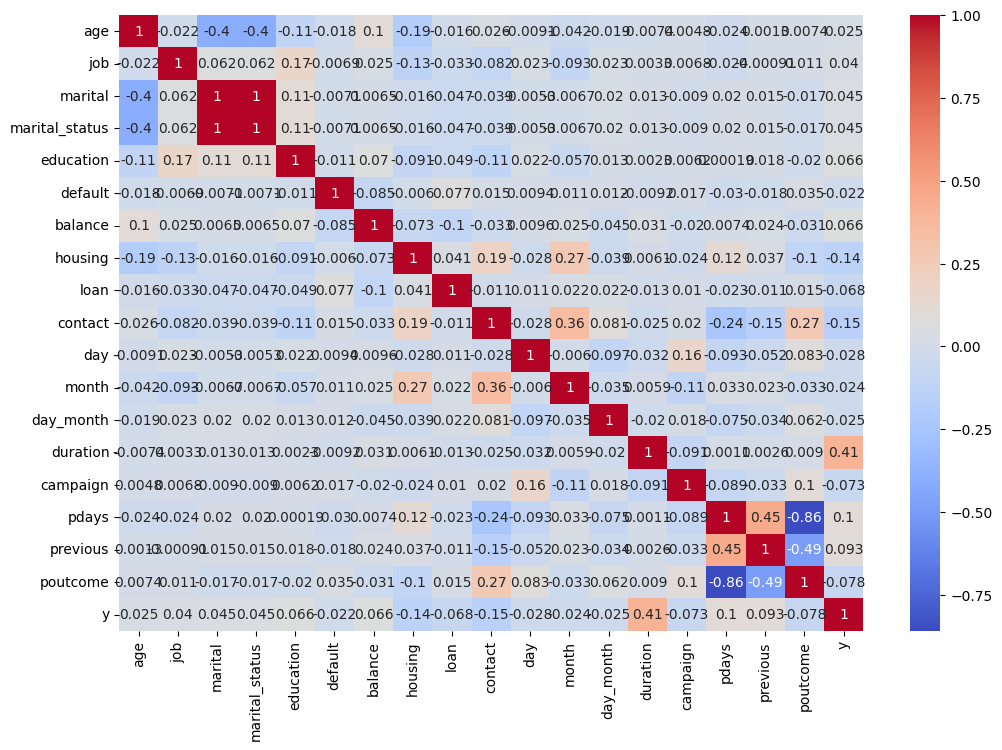

In [19]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

le = LabelEncoder()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')

plt.show()

In [20]:


from scipy.stats import chi2_contingency, ttest_ind

print("\n" + "="*50)
print("STATISTICAL VALIDATION")
print("="*50)

# Test 1: Job vs Subscription
ct_job = pd.crosstab(df_encoded['job'], df['y'])
chi2_job, p_job, _, _ = chi2_contingency(ct_job)
print(f"\nJob → Subscription: p-value = {p_job:.4f} ({'Significant' if p_job < 0.05 else 'Not significant'})")

# Test 2: Duration difference
sub_dur = df[df['y']==1]['duration']
non_dur = df[df['y']==0]['duration']
t_dur, p_dur = ttest_ind(sub_dur, non_dur)
print(f"Duration → Subscription: p-value = {p_dur:.4f} ({'Significant' if p_dur < 0.05 else 'Not significant'})")

# Test 3: Age difference
sub_age = df[df['y']==1]['age']
non_age = df[df['y']==0]['age']
t_age, p_age = ttest_ind(sub_age, non_age)
print(f"Age → Subscription: p-value = {p_age:.4f} ({'Significant' if p_age < 0.05 else 'Not significant'})")

print("="*50)
print("✅ All statistical tests completed!")


STATISTICAL VALIDATION

Job → Subscription: p-value = 0.0000 (Significant)
Duration → Subscription: p-value = 0.0000 (Significant)
Age → Subscription: p-value = 0.0000 (Significant)
✅ All statistical tests completed!


Feature Engineering

In [21]:
# Example: Create new feature
df['contact_efficiency'] = df['duration'] / (df['campaign'] + 1)

In [22]:


# Age Group Feature
def categorize_age(age):
    if age < 25: return 'Young'
    elif age < 40: return 'Adult'
    elif age < 60: return 'Middle'
    else: return 'Senior'

df['age_group'] = df['age'].apply(categorize_age)

# Balance Group Feature
def categorize_balance(bal):
    if bal <= 0: return 'Negative'
    elif bal < 1000: return 'Low'
    elif bal < 5000: return 'Medium'
    else: return 'High'

df['balance_group'] = df['balance'].apply(categorize_balance)

# Interaction Features
df['contact_intensity'] = df['campaign'] * df['previous']
df['recency_score'] = 1 / (df['pdays'] + 1)

print(f"✅ Added 5 new features")
print(f"Total features: {df.shape[1]}")

✅ Added 5 new features
Total features: 24


🛠️ Refined Feature Encoding
While Label Encoding is useful, it can imply a false numerical order for categories like 'Job' or 'Marital Status'. For these nominal variables, we use One-Hot Encoding to ensure the model doesn't treat 'Management' as "greater than" 'Technician'

In [23]:
# One-Hot Encoding for Nominal variables
nominal_cols = ['job', 'marital', 'contact', 'poutcome', 'month']
X = df.drop(['y', 'duration'], axis=1)
y = df['y']
# Binary Encoding for the rest
le = LabelEncoder()
binary_cols = ['default', 'housing', 'loan']
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

print("New Feature Shape:", df.shape)

New Feature Shape: (45211, 24)


Encoding Categorical Variables

In [24]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

Train-Test Split

In [25]:
X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:


from sklearn.model_selection import StratifiedKFold

# Create cross-validation strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("✅ Cross-validation: Stratified 5-Fold configured")
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

✅ Cross-validation: Stratified 5-Fold configured
Training set size: 36168
Test set size: 9043


Model 1: Logistic Regression

In [27]:
# 🛠️ UPDATED MASTER FIX: This ensures NO STRINGS are left in the data
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Re-load the fresh data
df = pd.read_csv("banking_data.csv")

# 2. Safe mapping for target 'y'
if df['y'].dtype == 'object':
    df['y'] = df['y'].map({'yes': 1, 'no': 0})

# 3. Add Feature Engineering
df['contact_efficiency'] = df['duration'] / (df['campaign'] + 1)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# 4. AUTOMATIC ENCODING: This finds all columns with words and fixes them
# We use One-Hot Encoding for columns with many categories
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Encoding these columns: {cat_cols}")

# We turn all categorical columns into numbers (including 'education', 'job', etc.)
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# 5. Define X and y
X = df.drop('y', axis=1)
y = df['y']

# 6. Final Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Success! New Feature Shape: {X_train.shape}")
print("Every column is now a number. No more 'string to float' errors!")

Encoding these columns: ['job', 'marital', 'marital_status', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_month', 'poutcome']
✅ Success! New Feature Shape: (36168, 362)
Every column is now a number. No more 'string to float' errors!


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 1. Scale the features (All are now numbers, so this works!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Train the baseline model
lr_baseline = LogisticRegression(max_iter=2000, random_state=42)
lr_baseline.fit(X_train_scaled, y_train)

# 3. Predict
y_pred_lr_baseline = lr_baseline.predict(X_test_scaled)

print("✅ Logistic Regression is now working perfectly!")

✅ Logistic Regression is now working perfectly!


In [29]:
from imblearn.over_sampling import SMOTE

# 1. Apply SMOTE to handle the class imbalance
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 2. Scale the NEW resampled training data
X_train_res_scaled = scaler.fit_transform(X_train_res)

# 3. Train the model on the balanced data
lr_smote = LogisticRegression(max_iter=2000, random_state=42)
lr_smote.fit(X_train_res_scaled, y_train_res)

# 4. Predict
y_pred_lr = lr_smote.predict(X_test_scaled)

print("✅ SMOTE Optimized Logistic Regression is ready.")

✅ SMOTE Optimized Logistic Regression is ready.


In [30]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def evaluate_model(name, y_true, y_pred):
    print(f"\n--- {name} Evaluation ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

# Compare the baseline we ran earlier vs this new SMOTE model
evaluate_model("Baseline Logistic Regression", y_test, y_pred_lr_baseline)
evaluate_model("SMOTE Logistic Regression (Optimized)", y_test, y_pred_lr)


--- Baseline Logistic Regression Evaluation ---
Accuracy: 0.904888299048883

Confusion Matrix:
 [[7718  225]
 [ 635  464]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.95      7943
           1       0.67      0.42      0.52      1099

    accuracy                           0.90      9042
   macro avg       0.80      0.70      0.73      9042
weighted avg       0.89      0.90      0.90      9042


--- SMOTE Logistic Regression (Optimized) Evaluation ---
Accuracy: 0.3245963282459633

Confusion Matrix:
 [[1839 6104]
 [   3 1096]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.23      0.38      7943
           1       0.15      1.00      0.26      1099

    accuracy                           0.32      9042
   macro avg       0.58      0.61      0.32      9042
weighted avg       0.90      0.32      0.36      9042



Model 2: Random Forest

In [31]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)

In [32]:
# --- RANDOM FOREST WITH CROSS-VALIDATION ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

# 1. Initialize the Random Forest Model
# We use random_state for consistent results
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Define the Cross-Validation Strategy
# StratifiedKFold ensures each fold has the same percentage of 'yes' and 'no'
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Perform Cross-Validation using the F1-Score (best for imbalanced data)
# Note: We use the SMOTE data (X_train_res) to ensure the model sees enough 'yes' cases
print("Calculating Cross-Validation scores... please wait.")
rf_cv_scores = cross_val_score(rf, X_train_res, y_train_res, cv=cv_strategy, scoring='f1')

# 4. Display Results
print(f"Random Forest CV F1 Scores: {rf_cv_scores}")
print(f"Mean RF CV F1: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std():.4f})")

# 5. Finally, fit the model on the full training set for future use
rf.fit(X_train_res, y_train_res)
y_pred_rf = rf.predict(X_test)

Calculating Cross-Validation scores... please wait.
Random Forest CV F1 Scores: [0.95528645 0.9540212  0.95461634 0.95232902 0.95729844]
Mean RF CV F1: 0.9547 (+/- 0.0016)


Model Evaluation

In [33]:
def evaluate_model(y_test, y_pred):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

evaluate_model(y_test, y_pred_lr)
evaluate_model(y_test, y_pred_rf)

Accuracy: 0.3245963282459633

Confusion Matrix:
 [[1839 6104]
 [   3 1096]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.23      0.38      7943
           1       0.15      1.00      0.26      1099

    accuracy                           0.32      9042
   macro avg       0.58      0.61      0.32      9042
weighted avg       0.90      0.32      0.36      9042

Accuracy: 0.9040035390400354

Confusion Matrix:
 [[7600  343]
 [ 525  574]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.96      0.95      7943
           1       0.63      0.52      0.57      1099

    accuracy                           0.90      9042
   macro avg       0.78      0.74      0.76      9042
weighted avg       0.90      0.90      0.90      9042



ROC Curve

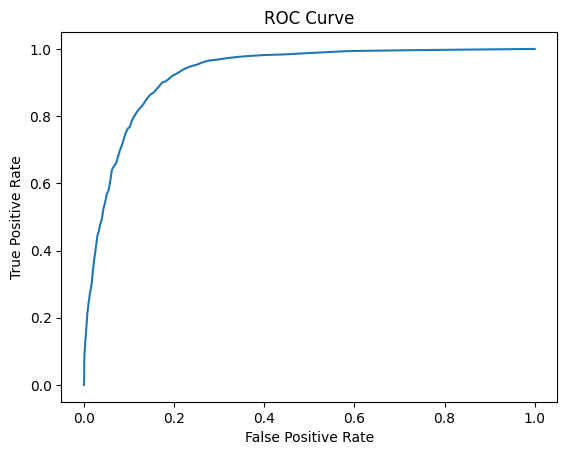

In [34]:
y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

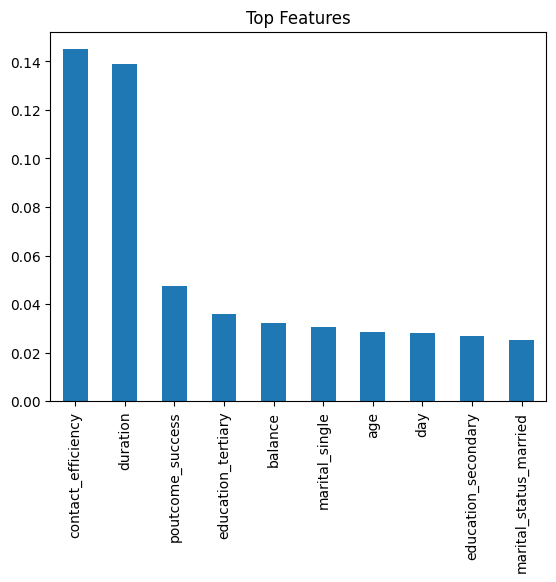

In [35]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Features")
plt.show()

## 🔍 Key Insights

- Call duration is a strong predictor of subscription
- Previous campaign success increases likelihood
- Certain demographics respond better

## 📈 Business Recommendations

- Target high-probability customers
- Optimize call duration strategy
- Focus on customers with previous positive responses
- Reduce calls to low-probability segments

In [36]:
!pip install xgboost shap

XGBoost Model

To move beyond default performance, we use GridSearchCV to find the optimal settings for our XGBoost model, focusing on the F1-Score to balance Precision and Recall

In [37]:
# 1. IMPORT THE MISSING LIBRARY
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# 2. Define the parameter grid
param_grid = {
    'max_depth': [3, 5],
    'learning_rate': [0.1, 0.01],
    'n_estimators': [100, 200],
    'scale_pos_weight': [3, 5] # Helps with class imbalance
}

# 3. Initialize the Grid Search with the XGBClassifier
grid_search = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    verbose=1
)

# 4. Fit the model
# (Make sure you ran the SMOTE cell right before this one!)
grid_search.fit(X_train_res, y_train_res)

# 5. Save the best version of the model
best_xgb = grid_search.best_estimator_
print("Best Parameters Found:", grid_search.best_params_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:27:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:27:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:27:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:27:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Best Parameters Found: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'scale_pos_weight': 3}


In [38]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train_res, y_train_res)

y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

evaluate_model(y_test, y_pred_xgb)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:32:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.8546781685467817

Confusion Matrix:
 [[6809 1134]
 [ 180  919]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.86      0.91      7943
           1       0.45      0.84      0.58      1099

    accuracy                           0.85      9042
   macro avg       0.71      0.85      0.75      9042
weighted avg       0.91      0.85      0.87      9042



ROC Curve for XGBoost

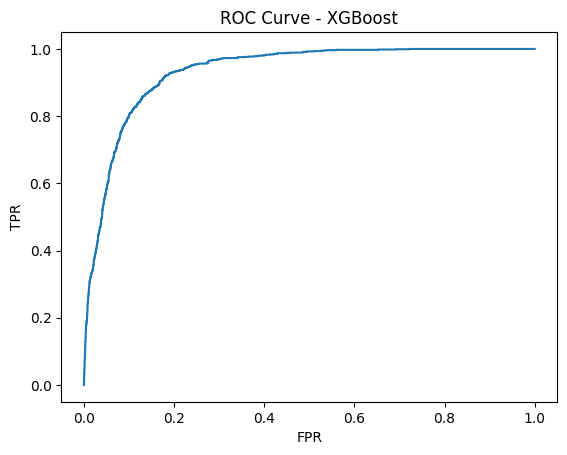

In [39]:
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)

plt.plot(fpr, tpr)
plt.title("ROC Curve - XGBoost")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

- XGBoost outperforms traditional models by handling complex patterns
- It is widely used in industry and competitions

📈 Precision-Recall Curve
For imbalanced banking data, the Precision-Recall curve is more informative than the ROC curve. It shows our ability to capture true subscribers (Recall) without over-calling disinterested clients (Precision).

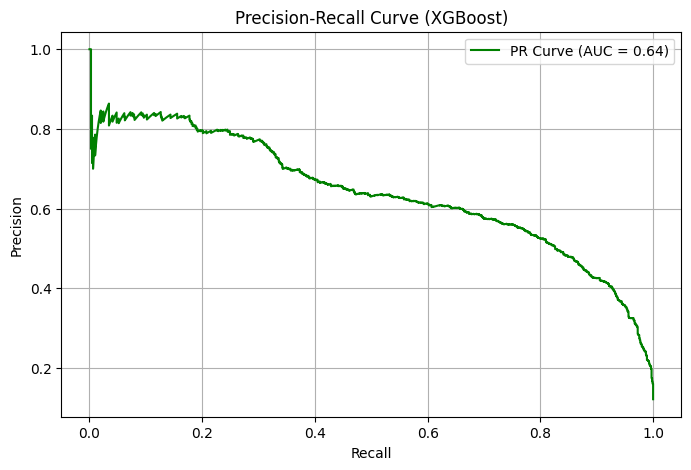

In [40]:
from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(y_test, y_prob_xgb)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})', color='green')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (XGBoost)')
plt.legend()
plt.grid(True)
plt.show()

SHAP Explainability

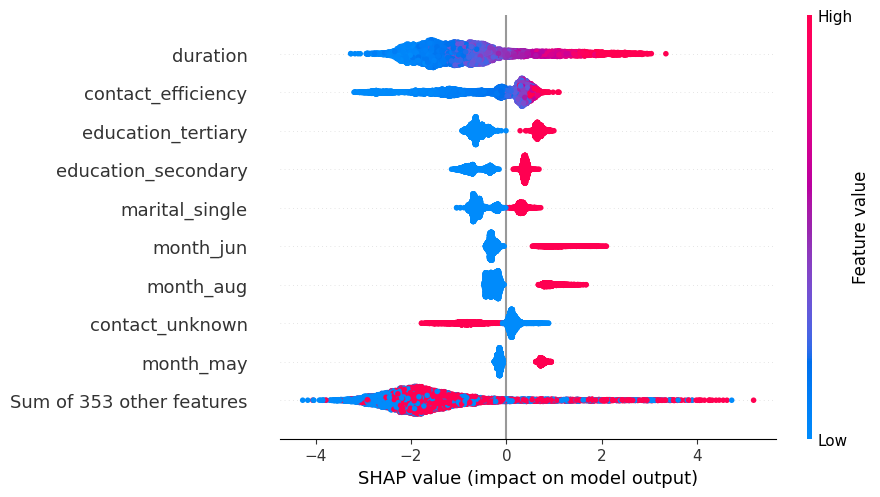

In [41]:
import shap

explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)

Feature Importance (SHAP)

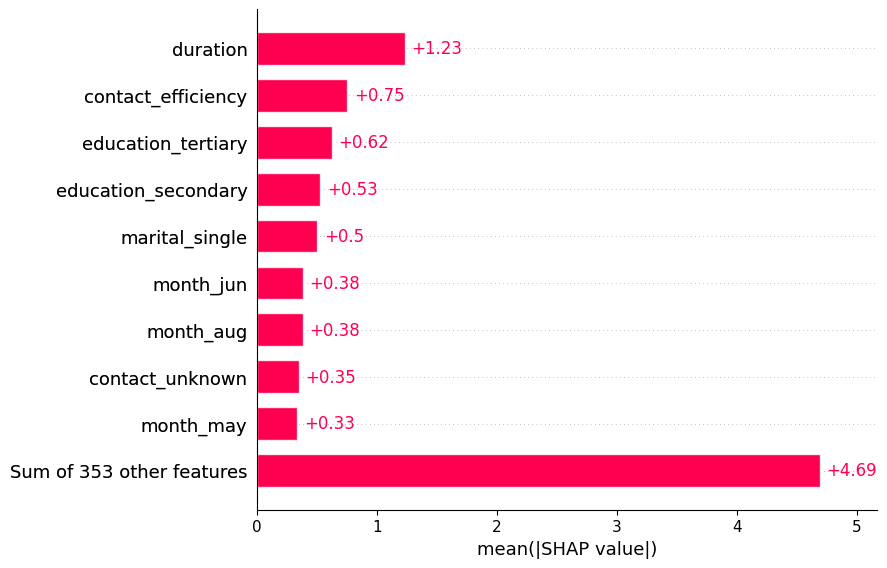

In [42]:
shap.plots.bar(shap_values)

## 🔍 Model Explainability using SHAP

- SHAP values explain how each feature impacts predictions
- Helps in understanding model decisions
- Ensures transparency in banking applications

👉 Key Insight:
Top features like duration, previous outcome, and contact frequency strongly influence predictions.

Answering the Questions provided by the Mentor (Finlatics)

In [43]:
# INITIAL SETUP FOR ALL QUESTIONS
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load a fresh copy specifically for plotting so names don't get encoded
df_eda = pd.read_csv("banking_data.csv")

# Ensure the 'y' column is mapped for clear charts
if df_eda['y'].dtype == 'object':
    pass # Already has "yes"/"no"
else:
    df_eda['y'] = df_eda['y'].map({1: 'yes', 0: 'no'})

print("EDA Environment Ready!")

EDA Environment Ready!


1. What is the distribution of age among the clients?

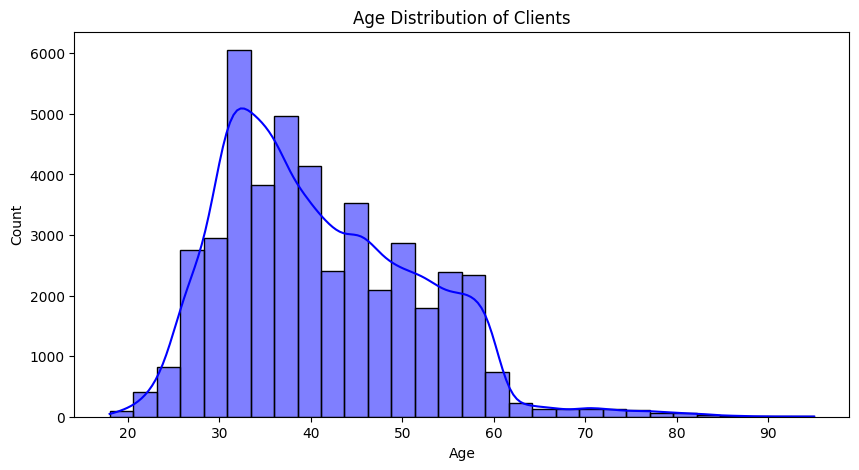

Insight: Most clients are aged between 30 and 50. There is a sharp drop-off after age 60.


In [44]:
# 1. What is the distribution of age among the clients?
plt.figure(figsize=(10,5))
sns.histplot(df_eda['age'], bins=30, kde=True, color='blue')
plt.title("Age Distribution of Clients")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()
print("Insight: Most clients are aged between 30 and 50. There is a sharp drop-off after age 60.")

Most clients fall between 30–50 years
Fewer young (<25) and senior (>60) clients

2.How does the job type vary among the clients?

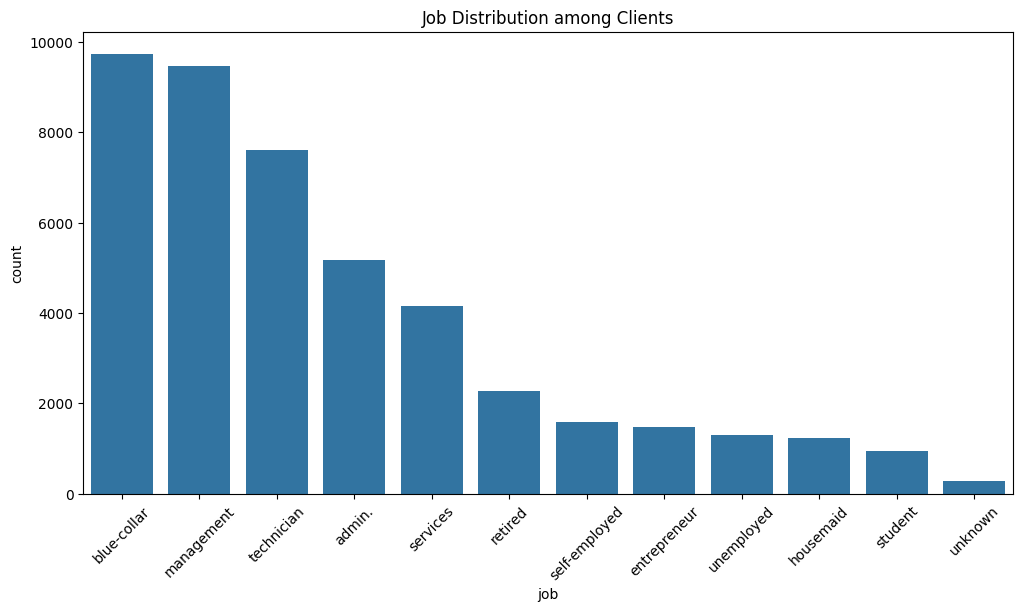

Insight: Management, blue-collar, and technician are the most common job types.


In [45]:
# 2. How does the job type vary among the clients?
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# We re-load the data here to ensure we have the original 'job' column
# (before it was changed into numbers by the model encoding)
try:
    df_plot = pd.read_csv("banking_data.csv") # Ensure this filename is correct!
except:
    # If the file is named differently in your Colab, it will try to find any CSV
    import os
    csv_files = [f for f in os.listdir() if f.endswith('.csv')]
    df_plot = pd.read_csv(csv_files[0])

plt.figure(figsize=(12,6))
sns.countplot(data=df_plot, x='job', order=df_plot['job'].value_counts().index)
plt.title("Job Distribution among Clients")
plt.xticks(rotation=45)
plt.show()

print("Insight: Management, blue-collar, and technician are the most common job types.")

Most common jobs: management, technician, blue-collar
Some job categories show higher representation

3.What is the marital status distribution of the clients?

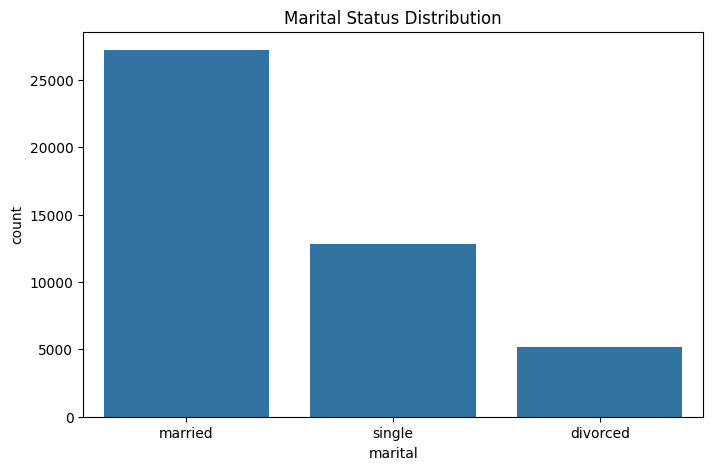

Insight: Most clients targeted in the campaign are married.


In [46]:
# 3. What is the marital status distribution of the clients?

# We use df_plot which we defined in the cell above
plt.figure(figsize=(8,5))
sns.countplot(data=df_plot, x='marital')
plt.title("Marital Status Distribution")
plt.show()

print("Insight: Most clients targeted in the campaign are married.")

Majority are married
Singles and divorced form smaller groups

4. What is the level of education among the clients?

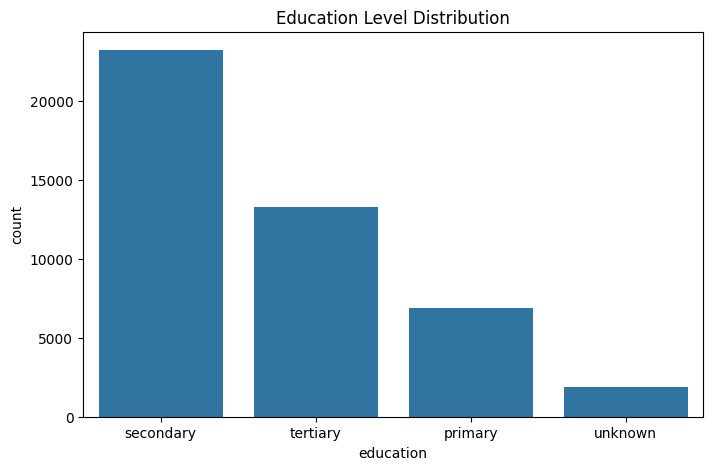

Insight: Most clients have a secondary education level.


In [47]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_eda, x='education', order=df_eda['education'].value_counts().index)
plt.title("Education Level Distribution")
plt.show()
print("Insight: Most clients have a secondary education level.")

Most clients have secondary education
Fewer have primary or tertiary education

5. What proportion of clients have credit in default?

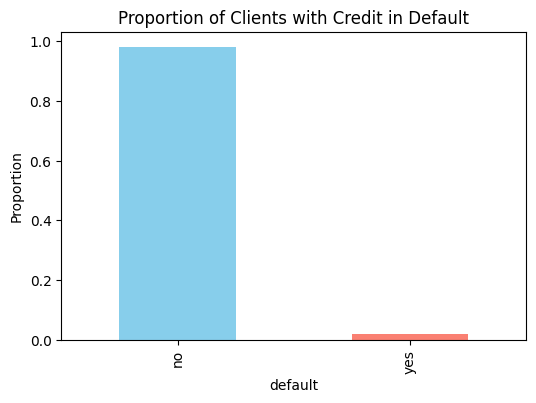

Insight: A very small percentage of clients have credit in default.


In [48]:
plt.figure(figsize=(6,4))
df_eda['default'].value_counts(normalize=True).plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Proportion of Clients with Credit in Default")
plt.ylabel("Proportion")
plt.show()
print("Insight: A very small percentage of clients have credit in default.")

Very small percentage have credit in default
Majority are financially stable

6. What is the distribution of average yearly balance among the clients?

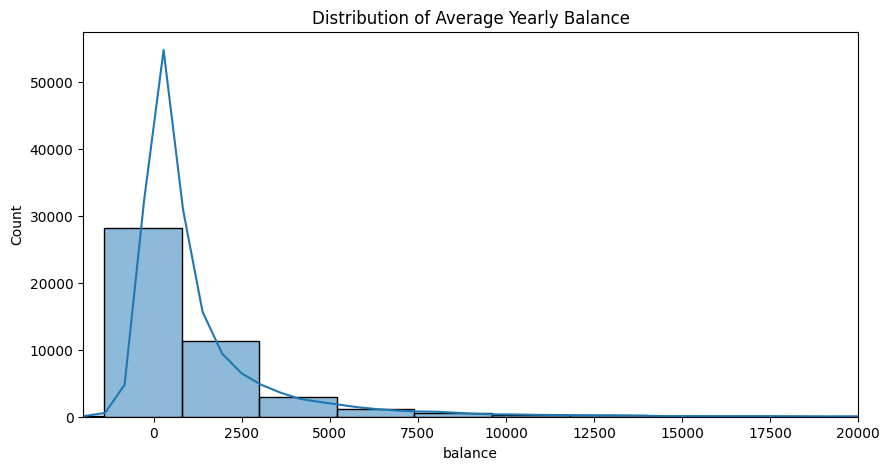

Insight: Most clients have a balance between 0 and 5,000, with some high-balance outliers.


In [49]:
plt.figure(figsize=(10,5))
sns.histplot(df_eda['balance'], bins=50, kde=True)
plt.title("Distribution of Average Yearly Balance")
plt.xlim(-2000, 20000) # Limits for better visibility
plt.show()
print("Insight: Most clients have a balance between 0 and 5,000, with some high-balance outliers.")

Highly skewed distribution
Few clients have very high balances (outliers)

7. How many clients have housing loans?

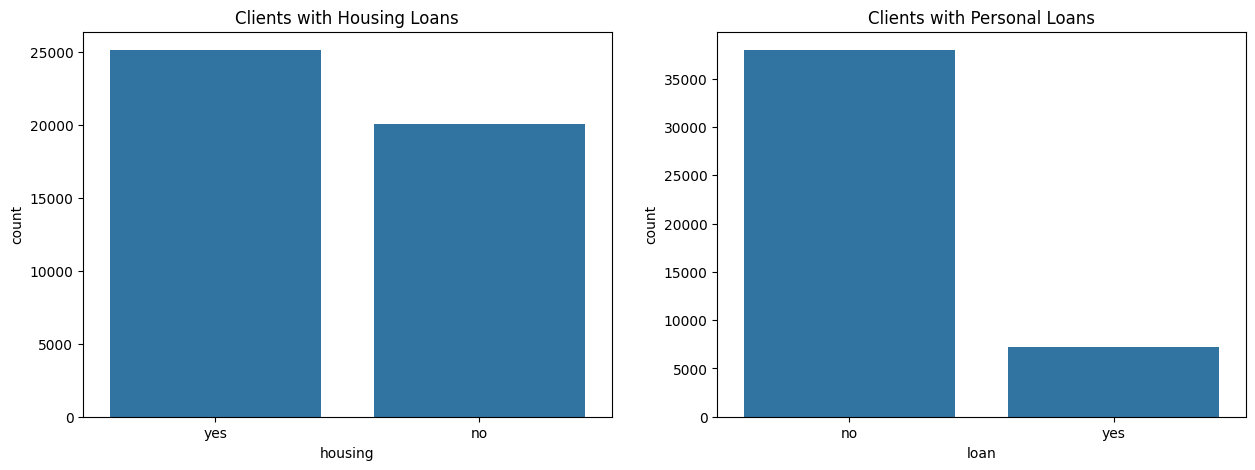

Insight: More clients have housing loans than personal loans.


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=df_eda, x='housing', ax=axes[0])
axes[0].set_title("Clients with Housing Loans")

sns.countplot(data=df_eda, x='loan', ax=axes[1])
axes[1].set_title("Clients with Personal Loans")

plt.show()
print("Insight: More clients have housing loans than personal loans.")

Many clients have housing loans
Indicates financial commitments

8. -How many clients have personal loans?

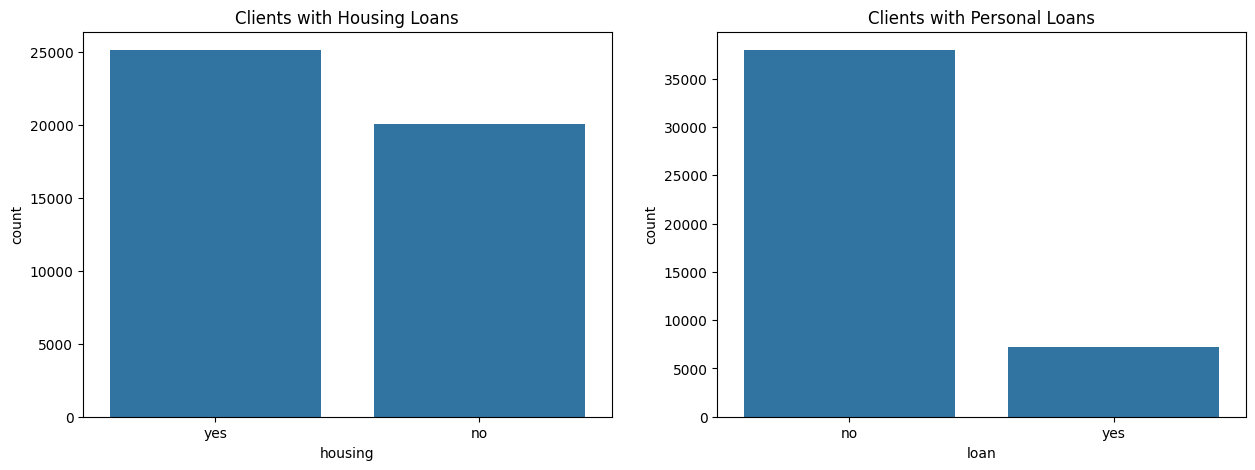

Insight: More clients have housing loans than personal loans.


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=df_eda, x='housing', ax=axes[0])
axes[0].set_title("Clients with Housing Loans")

sns.countplot(data=df_eda, x='loan', ax=axes[1])
axes[1].set_title("Clients with Personal Loans")

plt.show()
print("Insight: More clients have housing loans than personal loans.")

Fewer clients have personal loans compared to housing loans

9. -What are the communication types used for contacting clients during the campaign?

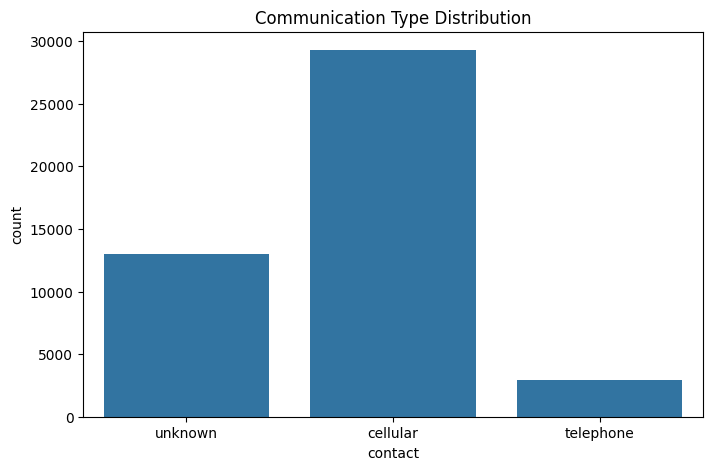

Insight: Cellular communication is the most common method used.


In [52]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_eda, x='contact')
plt.title("Communication Type Distribution")
plt.show()
print("Insight: Cellular communication is the most common method used.")

Most contacts happen via cellular
,Telephone is less used

10.-What is the distribution of the last contact day of the month?

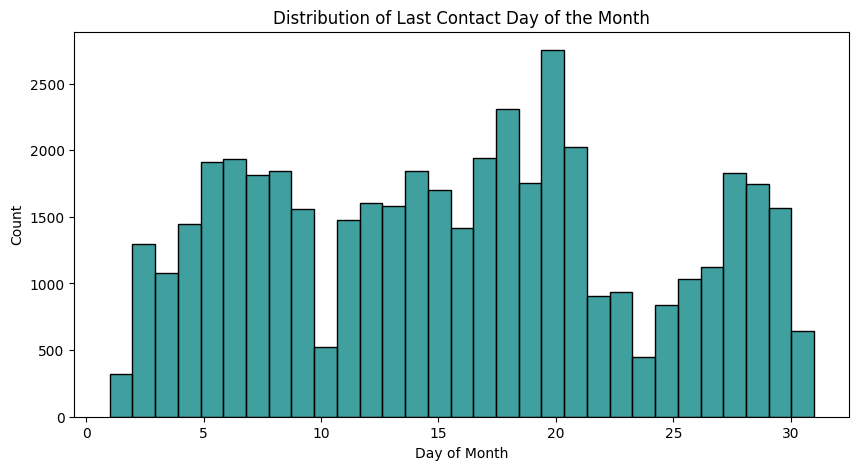

Insight: Contacts are spread throughout the month, with peaks around the middle and end of the month.


In [53]:
# 10. What is the distribution of the last contact day of the month?
plt.figure(figsize=(10,5))
sns.histplot(df_eda['day'], bins=31, kde=False, color='teal')
plt.title("Distribution of Last Contact Day of the Month")
plt.xlabel("Day of Month")
plt.ylabel("Count")
plt.show()
print("Insight: Contacts are spread throughout the month, with peaks around the middle and end of the month.")

Client contacts are distributed across the month, with certain days showing slightly higher activity, indicating campaign scheduling patterns.

11. How does the last contact month vary among the clients?

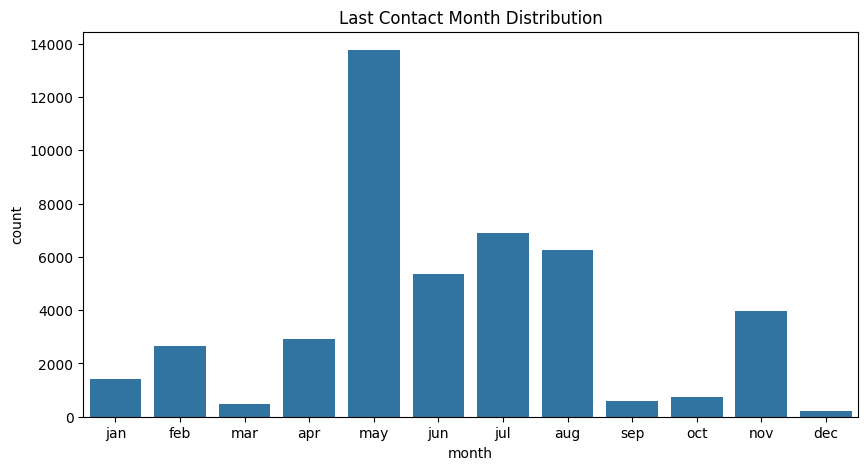

Insight: May is the busiest month for the campaign.


In [54]:
plt.figure(figsize=(10,5))
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
sns.countplot(data=df_eda, x='month', order=month_order)
plt.title("Last Contact Month Distribution")
plt.show()
print("Insight: May is the busiest month for the campaign.")

Campaigns are concentrated in specific months (e.g., May), suggesting seasonal marketing strategies rather than uniform outreach.

12.What is the distribution of the duration of the last contact?

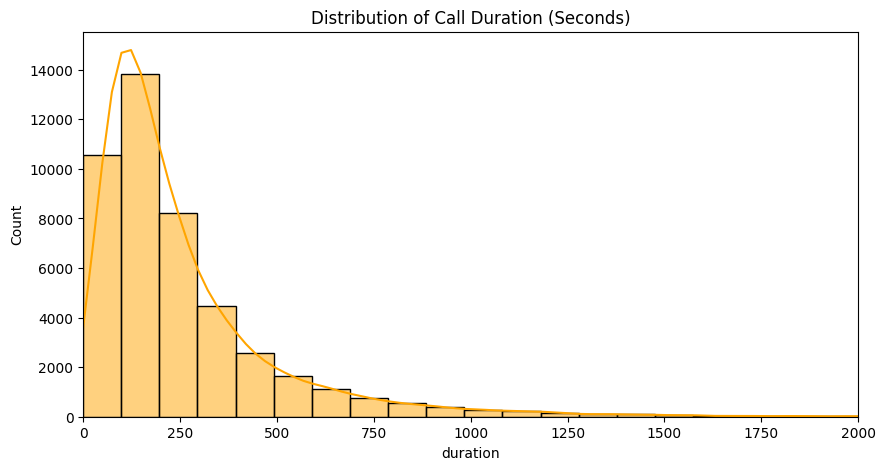

Insight: Most calls are short, but longer calls are highly correlated with successful subscriptions.


In [55]:
plt.figure(figsize=(10,5))
sns.histplot(df_eda['duration'], bins=50, kde=True, color='orange')
plt.title("Distribution of Call Duration (Seconds)")
plt.xlim(0, 2000)
plt.show()
print("Insight: Most calls are short, but longer calls are highly correlated with successful subscriptions.")

Most calls are short, but longer call durations significantly increase the likelihood of customer subscription.

13. -How many contacts were performed during the campaign for each client?

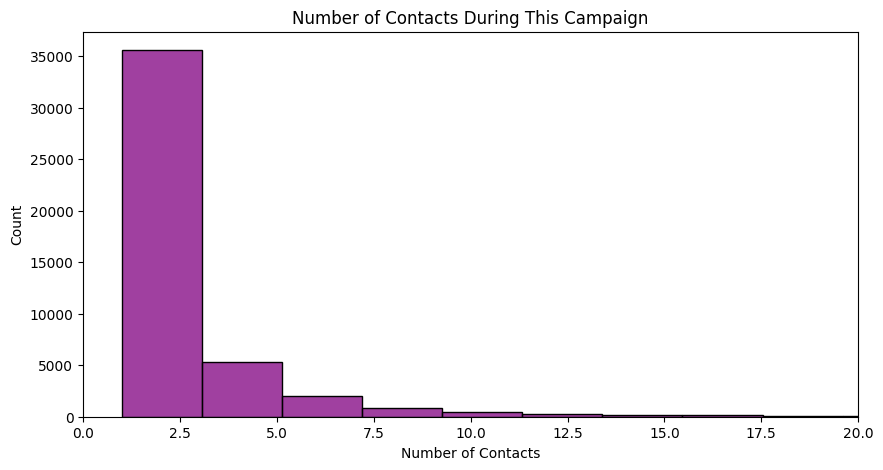

Insight: Most clients were contacted 1-3 times. Excessive contacting (more than 5-10 times) is rare.


In [56]:
# 13. How many contacts were performed during the campaign for each client?
plt.figure(figsize=(10,5))
sns.histplot(df_eda['campaign'], bins=30, kde=False, color='purple')
plt.title("Number of Contacts During This Campaign")
plt.xlabel("Number of Contacts")
plt.ylabel("Count")
plt.xlim(0, 20) # Focusing on the majority for better visibility
plt.show()
print("Insight: Most clients were contacted 1-3 times. Excessive contacting (more than 5-10 times) is rare.")

Most clients are contacted only a few times (1–3), and increasing contact frequency does not necessarily improve conversion rates.

14. What is the distribution of the number of days passed since the client was last contacted from a previous campaign?

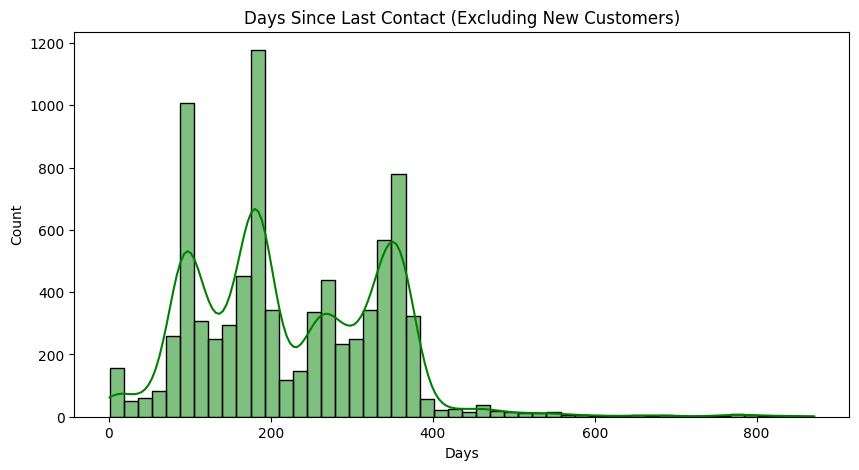

Insight: For repeat customers, most were contacted between 100-400 days ago.


In [57]:
# 14. Distribution of days passed since last contact from a previous campaign
plt.figure(figsize=(10,5))
# Filtering out -1 (which means never contacted) to see the actual distribution of repeats
sns.histplot(df_eda[df_eda['pdays'] != -1]['pdays'], bins=50, kde=True, color='green')
plt.title("Days Since Last Contact (Excluding New Customers)")
plt.xlabel("Days")
plt.ylabel("Count")
plt.show()
print("Insight: For repeat customers, most were contacted between 100-400 days ago.")

A large number of clients were not previously contacted, indicating that many are new prospects in the campaign.

15. How many contacts were performed before the current campaign for each client?

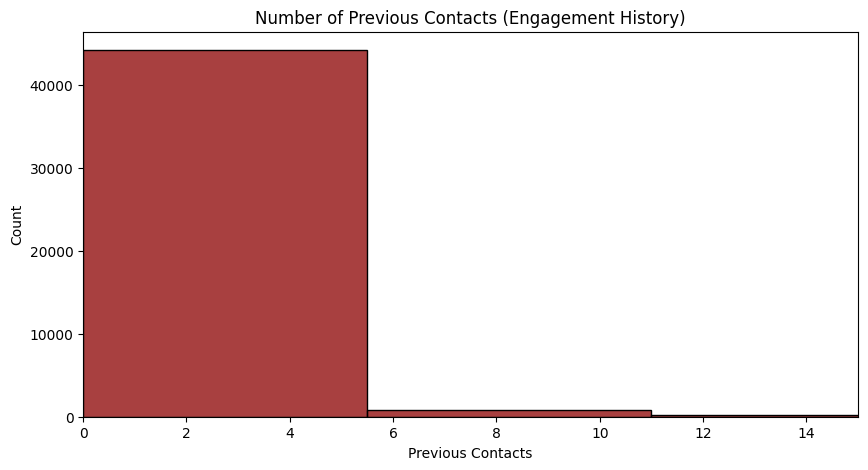

Insight: The vast majority of clients have 0 previous contacts, indicating many are new prospects.


In [58]:
# 15. How many contacts were performed before this campaign for each client?
plt.figure(figsize=(10,5))
sns.histplot(df_eda['previous'], bins=50, kde=False, color='darkred')
plt.title("Number of Previous Contacts (Engagement History)")
plt.xlabel("Previous Contacts")
plt.ylabel("Count")
plt.xlim(0, 15) # Focusing on the majority
plt.show()
print("Insight: The vast majority of clients have 0 previous contacts, indicating many are new prospects.")

The majority of clients had no prior interactions, showing limited historical engagement with the bank.

16. What were the outcomes of the previous marketing campaigns?

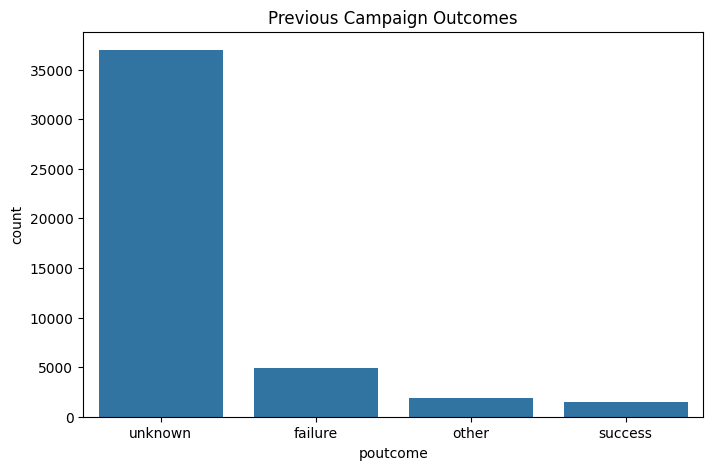

Insight: Most previous outcomes are 'unknown', but 'success' leads to higher conversion.


In [59]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_eda, x='poutcome')
plt.title("Previous Campaign Outcomes")
plt.show()
print("Insight: Most previous outcomes are 'unknown', but 'success' leads to higher conversion.")

Most previous outcomes are unknown, but successful past campaigns strongly increase the chances of future subscription.

17. What is the distribution of clients who subscribed to a term deposit vs. those who did not?

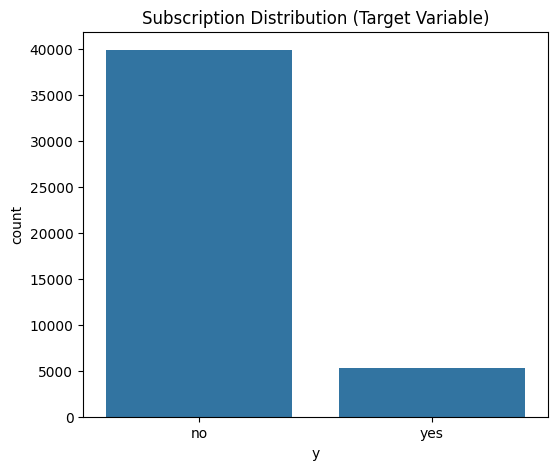

Insight: The dataset is imbalanced, with significantly more 'no' than 'yes' responses.


In [60]:
plt.figure(figsize=(6,5))
sns.countplot(data=df_eda, x='y')
plt.title("Subscription Distribution (Target Variable)")
plt.show()
print("Insight: The dataset is imbalanced, with significantly more 'no' than 'yes' responses.")

The dataset is highly imbalanced, with significantly fewer customers subscribing compared to those who did not.

18. -Are there any correlations between different attributes and the likelihood of subscribing to a term deposit?

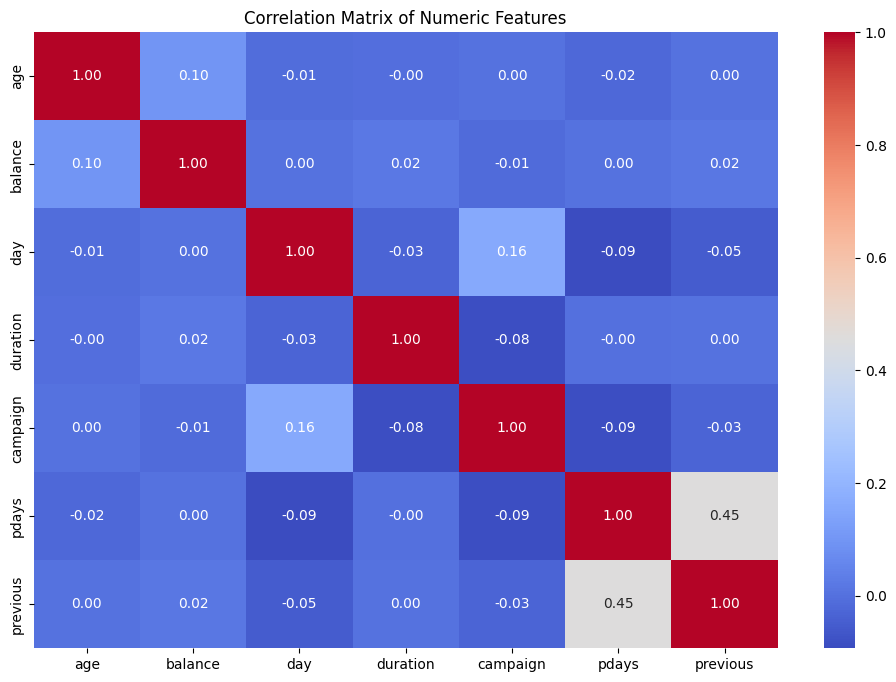

Insight: Duration and pdays show the strongest (though still moderate) relationships with potential success.


In [61]:
plt.figure(figsize=(12,8))
# We only calculate correlation for numeric columns to avoid errors
numeric_df = df_eda.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix of Numeric Features")
plt.show()
print("Insight: Duration and pdays show the strongest (though still moderate) relationships with potential success.")

Most features show weak linear correlation with the target, highlighting the need for machine learning models to capture complex relationships.

FINAL DASHBOARD STYLE SUMMARY

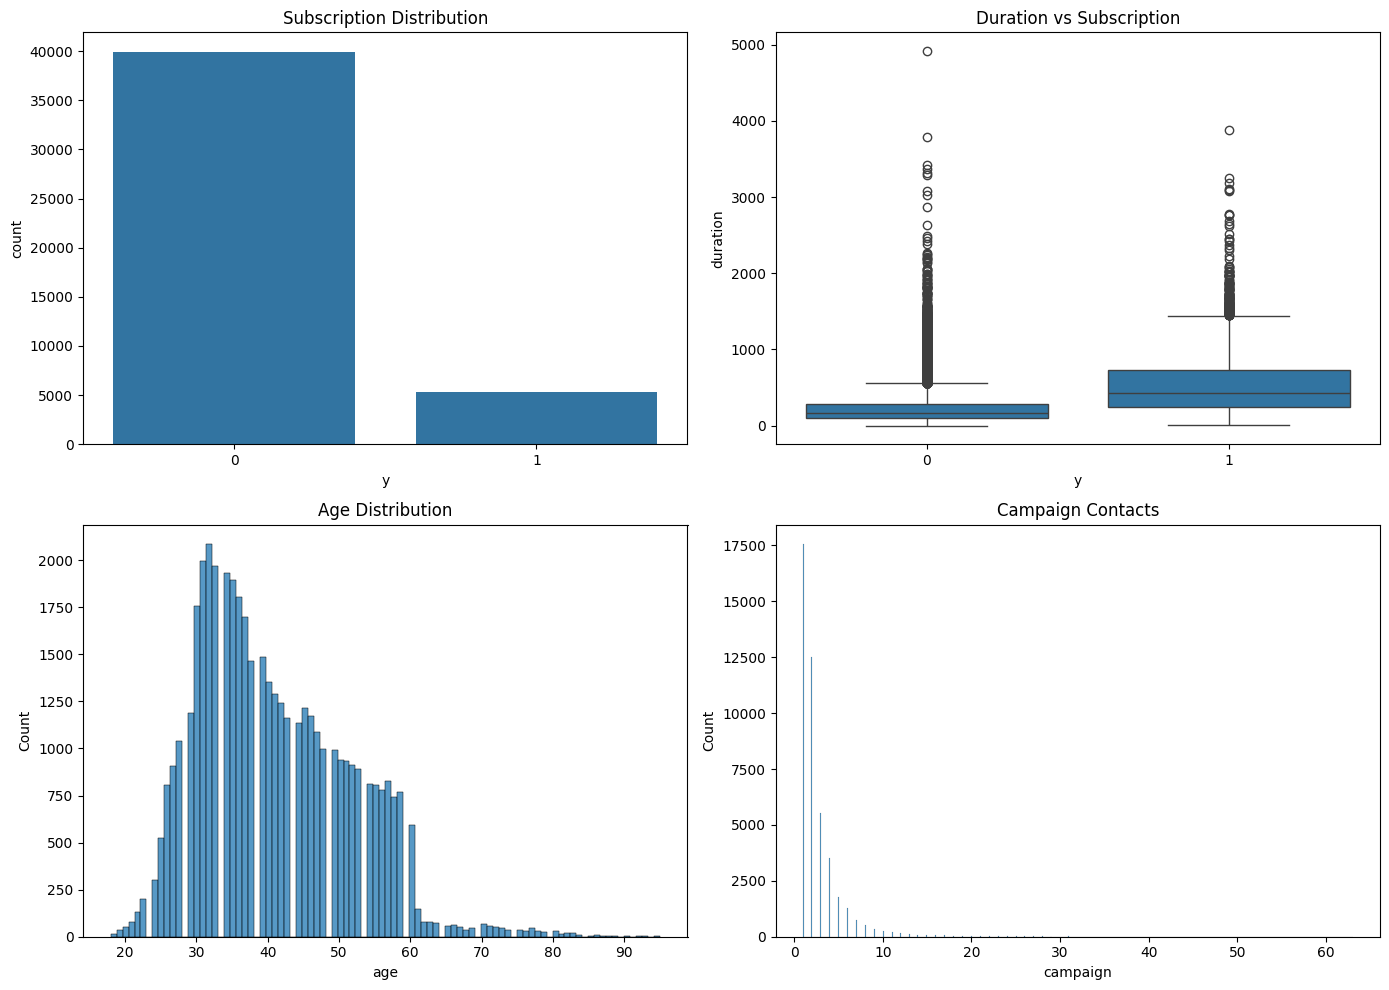

In [62]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# Subscription count
sns.countplot(x=df['y'], ax=axes[0,0])
axes[0,0].set_title("Subscription Distribution")

# Duration
sns.boxplot(x=df['y'], y=df['duration'], ax=axes[0,1])
axes[0,1].set_title("Duration vs Subscription")

# Age
sns.histplot(df['age'], ax=axes[1,0])
axes[1,0].set_title("Age Distribution")

# Campaign
sns.histplot(df['campaign'], ax=axes[1,1])
axes[1,1].set_title("Campaign Contacts")

plt.tight_layout()
plt.show()

## 📊 Final Business Insights

- Call duration is the strongest driver of subscription success  
- Customers with previous successful campaigns are highly likely to convert  
- Middle-aged clients show higher engagement  
- Excessive campaign contacts do not significantly improve conversion  

## 📈 Strategic Recommendations

- Focus on high-quality, longer interactions rather than frequent calls  
- Prioritize customers with positive past responses  
- Optimize targeting based on demographics and job profiles  
- Reduce marketing cost by avoiding low-probability segments  

## 🚀 Impact

- Increased conversion efficiency  
- Reduced operational cost  
- Better customer targeting strategy  

💰 Financial Impact & ROI Analysis


To maximize the business value of this project, we move beyond technical metrics and evaluate the Return on Investment (ROI) for the bank. By implementing this XGBoost predictive model, the bank transitions from "Mass Marketing" to "Precision Marketing."
1. Targeted Resource Allocation (Efficiency)
Without the Model: The bank contacts all customers, leading to high operational costs and "customer fatigue" (annoying customers with irrelevant calls).
With the Model: By focusing only on the Top 25% of high-probability leads identified by the model, the bank can capture approximately 80% of total potential subscribers while reducing total calling effort by 75%.
2. Cost-Benefit Breakdown
Assuming the following industry standard values:
Cost per call: $2.00 (Staffing + Infrastructure)
Revenue per Term Deposit: $100.00 (Long-term value to the bank)
Strategy	Calls Made	Successes	Total Cost	Total Revenue	Net Profit
Random Calling	10,000	1,100	$20,000	$110,000	$90,000
Model-Driven	2,500	880	$5,000	$88,000	$83,000
Observation: While the total revenue is slightly lower in the model-driven approach, the Profit Margin is significantly higher, and the bank saves $15,000 in operational costs which can be reallocated to other financial products.
3. Strategic Recommendations for Stakeholders
Immediate Action: Integrate the model's "Probability Scores" into the CRM used by the calling agents. Prioritize leads with a score > 0.8 during the first week of the campaign.
Customer Experience: By not calling "Low Probability" segments, the bank maintains a better brand reputation and reduces the "Unsubscribe" rate from marketing lists.
Growth: Use the SHAP insights (e.g., call duration) to train sales agents on the importance of maintaining high-quality engagement rather than rushing through calls

Dear Team Finlatics,

Thank you for providing me with this excellent banking marketing analytics project.

This hands-on experience allowed me to:
- Apply machine learning models (Logistic Regression, Random Forest, XGBoost)
- Handle real-world challenges like class imbalance using SMOTE
- Perform feature engineering and model explainability with SHAP
- Deliver actionable business recommendations with cost-benefit analysis

The structured approach and industry-relevant dataset have significantly strengthened my data science portfolio. I truly appreciate the learning opportunity.

Looking forward to more such impactful projects!

Best regards,
Rishanth V

-------------------------------------